### Analysis of Drosophila melanogaster Mid-Infrared Spectra

This programme uses IR spectra to train 5 machine learning models to predict different bioloigcal characteristics in Drosophila melanogaster

Previously:
- The IR spectra were saved as .mzz (or .dpt) 
- Samples were subjected to pre-processing by running a previously developed script Bad Blood (https://github.com/magonji/bad-blood). Files with low-intensity peaks (spectrum intensity <0.1 at wavenumber 600 cm-1), abnormal background measurement (outliers at wavenumber 1900 cm-1), atmospheric interference (CO2 or water vapour-related interferences in region 3900-3500 cm-1) were discarded.
- Duplicates were discarded
- A matrix with all the information (.dat) was exported 

Written by Dr Rita Ibrahim and Dr Mario Gonzalez Jimenez

School of Molecular Biosciences and School of Molecular Chemistry,
University of Glasgow,
Glasgow G12 8QQ, UK.

 

#### Import all the required packages

In [ ]:

import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 
import matplotlib as mpl
from matplotlib.patches import Ellipse 
import seaborn as sns 
plt.style.use('seaborn-poster')
%matplotlib inline
from pathlib import Path 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import StratifiedShuffleSplit 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.manifold import TSNE
import matplotlib.lines as mlines

#### Define your function

This function:
- Ensures the data is in the right format with respect to each experiment analysed. 
- Prints sample sizes
- Determine features that are important using XGBoost
- Plots the spectra of the different labels
- Trains 5 ML models and tests their ability to re-classify samples based on e.g. sex, genotype etc.
- Presents the results as a confusion matrix
- Prints out the results as a .csv file to extract the accuracy values at each round of cross-validation
- If there is an independent test dataset, the model is tested to assess its generalisability
- Results are also presented as confusion matrices and as csv files
- Calculate average re-classification accuracy for each model ±SD

In [ ]:
def MIRSPIPELINE (data, testdata_presence, test_data, experiment, sex_dk, sensitives_file, resistants_file, feature2,
           plot_cols, labels, save_results_to, tSNE_colours, tSNE_order, styleofline):

    if not data:
        return "Error with data"
    else:
        data = pd.read_csv(Path(data), sep='\t')
        if testdata_presence=="Yes":
            test_data = pd.read_csv(Path(test_data), sep='\t')
        if experiment =='Sex':
            if sex_dk =="Yes":
                df_FF = data[data['Sex'] == 'F']
                df_MM = data[data['Sex'] == 'M']
                df_F_sampled = df_FF.sample(n=740, random_state=1)
                df_combined = pd.concat([df_F_sampled, df_MM], ignore_index=True)
                df_F = df_combined[df_combined['Sex'] == 'F']
                df_M = df_combined[df_combined['Sex'] == 'M']
                df_F_new = df_F.sample(n=493, random_state=1)
                df_F_fordk = df_F.drop(df_F_new.index)
                df_M_new = df_M.sample(n=493, random_state=1)
                df_M_fordk = df_M.drop(df_M_new.index)

                df_dk = pd.concat([df_F_fordk, df_M_fordk])

                data = pd.concat([df_F_new.assign(Sex2='F'), 
                                    df_M_new.assign(Sex2='M'), 
                                    df_dk.assign(Sex2='dk')])

                print(data['Sex2'].value_counts())
                #Order the labels
                order = {'F': 0, 'M': 1, 'dk': 2}
                data['Sex2'] = data['Sex2'].map(order)
                data['Sex2'] = pd.Categorical(data['Sex2'], categories=order.values(), ordered=True)
                data.sort_values(by='Sex2', inplace=True)
                data['Sex2'] = data['Sex2'].map({v: k for k, v in order.items()})

                #Change the order and bring Sex2:F, M, dk to front
                Sex2_col = data.columns[-1]
                changedorder = [Sex2_col] + list(data.columns[:-1])
                data = data[changedorder]
                selected_label=('Sex2')
            
            else: #if sex_dk is not 'Yes', order F and M
                order = {'F': 0, 'M': 1}
                data['Sex'] = data['Sex'].map(order)
                data['Sex'] = pd.Categorical(data['Sex'], categories=order.values(), ordered=True)
                data.sort_values(by='Sex', inplace=True)
                data['Sex'] = data['Sex'].map({v: k for k, v in order.items()})
                selected_label=('Sex')
                #Also order the test_data labels
                if testdata_presence=="Yes":
                    test_data['Sex'] = test_data['Sex'].map(order)
                    test_data['Sex'] = pd.Categorical(test_data['Sex'], categories=order.values(), ordered=True)
                    test_data.sort_values(by='Sex', inplace=True)
                    test_data['Sex'] = test_data['Sex'].map({v: k for k, v in order.items()})
            
        elif experiment =="4 Genos":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="AA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="AB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="BA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="BB")
            data = data[data["Sex"] == "F"]
            #Order the labels
            order = {'AA': 0, 'AB': 1, 'BA': 2, 'BB':3}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            
        elif experiment =="AAvsBB":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="AA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="AB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="BA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="BB")
            data = data[data["Sex"] == "F"]
            data = data[(data["Genot."] == "BB") | (data["Genot."] == "AA")]
            #Order the labels
            order = {'AA': 0, 'BB': 1}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            
        elif experiment =="nuclear":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="nucA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="nucB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="nucA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="nucB")
            data = data[data["Sex"] == "F"]
            #Order the labels
            order = {'nucA': 0, 'nucB': 1}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            #Also order the labels in  test_data
            if testdata_presence=="Yes":
                test_data = test_data.replace(to_replace=["AA1", "AA2", "AA3"], value="nucA")
                test_data = test_data.replace(to_replace=["AB1", "AB2", "AB3"], value="nucB")
                test_data = test_data.replace(to_replace=["BA1", "BA2", "BA3"], value="nucA")
                test_data = test_data.replace(to_replace=["BB1", "BB2", "BB3"], value="nucB")
                test_data = test_data[test_data["Sex"] == "F"]
                order = {'nucA': 0, 'nucB': 1}
                test_data['Genot.'] = test_data['Genot.'].map(order)
                test_data['Genot.'] = pd.Categorical(test_data['Genot.'], categories=order.values(), ordered=True)
                test_data.sort_values(by='Genot.', inplace=True)
                test_data['Genot.'] = test_data['Genot.'].map({v: k for k, v in order.items()})
                
        elif experiment =="nuclear in mitoA":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="nucA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="nucB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="BA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="BB")
            data = data[data["Sex"] == "F"]
            data = data[(data["Genot."] == "nucA") | (data["Genot."] == "nucB")]
            #Order the labels
            order = {'nucA': 0, 'nucB': 1}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            
        elif experiment =="nuclear in mitoB":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="AA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="AB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="nucA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="nucB")
            data = data[data["Sex"] == "F"]
            data = data[(data["Genot."] == "nucA") | (data["Genot."] == "nucB")]
            #Order the labels
            order = {'nucA': 0, 'nucB': 1}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            
        elif experiment =="mito in nucA":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="mitoA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="AB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="mitoB")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="BB")
            data = data[data["Sex"] == "F"]
            data = data[(data["Genot."] == "mitoA") | (data["Genot."] == "mitoB")]
            #Order the labels
            order = {'mitoA': 0, 'mitoB': 1}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            
        elif experiment =="mito in nucB":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="AA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="mitoA")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="BA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="mitoB")
            data = data[data["Sex"] == "F"]
            data = data[(data["Genot."] == "mitoA") | (data["Genot."] == "mitoB")]
            #Order the labels
            order = {'mitoA': 0, 'mitoB': 1}
            data['Genot.'] = data['Genot.'].map(order)
            data['Genot.'] = pd.Categorical(data['Genot.'], categories=order.values(), ordered=True)
            data.sort_values(by='Genot.', inplace=True)
            data['Genot.'] = data['Genot.'].map({v: k for k, v in order.items()})
            selected_label=('Genot.')
            
        elif experiment =="Age":
            #Order the labels
            order = {'09D': 0, '04W': 1, '06W': 2}
            data['Age'] = data['Age'].map(order)
            data['Age'] = pd.Categorical(data['Age'], categories=order.values(), ordered=True)
            data.sort_values(by='Age', inplace=True)
            data['Age'] = data['Age'].map({v: k for k, v in order.items()})
            selected_label=('Age')
            
        elif experiment =="Diet1":
            #Order the labels
            order = {'SY': 0, 'LI': 1}
            data['Diet'] = data['Diet'].map(order)
            data['Diet'] = pd.Categorical(data['Diet'], categories=order.values(), ordered=True)
            data.sort_values(by='Diet', inplace=True)
            data['Diet'] = data['Diet'].map({v: k for k, v in order.items()})
            selected_label=('Diet')
            
        elif experiment =="Diet2": 
            #Order the labels
            order = {'D05': 0, 'D10': 1, 'D20': 2}
            data['Diet'] = data['Diet'].map(order)
            data['Diet'] = pd.Categorical(data['Diet'], categories=order.values(), ordered=True)
            data.sort_values(by='Diet', inplace=True)
            data['Diet'] = data['Diet'].map({v: k for k, v in order.items()})
            selected_label=('Diet')
            
        elif experiment=='DR_Age':
            data["DR_Age"] = data["Diet"] + data["Age"].astype(str) #make a DR_Age column
            data = data.drop(columns="Sex")
            data = data.drop(columns="Age")
            data = data.drop(columns="Genot.")
            data = data.drop(columns="Diet")
            
            cols = data.columns.tolist()
            cols = cols[-1:] + cols[:-1]
            data = data[cols] 
            
            #Order the labels
            order = {'D0509D': 0, 'D1009D': 1,'D2009D': 2, 'D0503W': 3, 'D1003W': 4, 'D2003W':5 }
            data['DR_Age'] = data['DR_Age'].map(order)
            data['DR_Age'] = pd.Categorical(data['DR_Age'], categories=order.values(), ordered=True)
            data.sort_values(by='DR_Age', inplace=True)
            data['DR_Age'] = data['DR_Age'].map({v: k for k, v in order.items()})
            selected_label = 'DR_Age'
            
        elif experiment =="SexMitoNuc":
            data = data.replace(to_replace=["AA1", "AA2", "AA3"], value="AA")
            data = data.replace(to_replace=["AB1", "AB2", "AB3"], value="AB")
            data = data.replace(to_replace=["BA1", "BA2", "BA3"], value="BA")
            data = data.replace(to_replace=["BB1", "BB2", "BB3"], value="BB")
            data["SexMitoNuc"] = data["Genot."] + '_' + data["Sex"].astype(str)
            #Order the labels
            order = {'AA_F': 0, 
                     'AA_M': 1, 
                     'AB_F': 2, 
                     'AB_M': 3, 
                     'BA_F': 4, 
                     'BA_M': 5, 
                     'BB_F': 6, 
                     'BB_M': 7}
            data['SexMitoNuc'] = data['SexMitoNuc'].map(order)
            data['SexMitoNuc'] = pd.Categorical(data['SexMitoNuc'], categories=order.values(), ordered=True)
            data.sort_values(by='SexMitoNuc', inplace=True)
            data['SexMitoNuc'] = data['SexMitoNuc'].map({v: k for k, v in order.items()})
            selected_label=('SexMitoNuc')
            cols = data.columns.tolist()
            cols = cols[-1:] + cols[:-1]
            data = data[cols] 
            
        elif experiment=="DGRP":
            data['Genot.'].unique()
            #Load the CSV files into DataFrames
            sensitives = pd.read_csv(Path(sensitives_file), sep='\t')
            resistants = pd.read_csv(Path(resistants_file), sep='\t')
            sensitives_val = set(sensitives['sensitive'])
            resistants_val = set(resistants['resistant'])
            #Label the samples as sensitive or resistant
            def check_value(value):
                if value in sensitives_val:
                    return 'Sensitive'
                elif value in resistants_val:
                    return 'Resistant'
                else:
                    return 'Average'
            data['starvation'] = data['Genot.'].apply(check_value)
            if len(labels)==2:
                data = data[(data["starvation"] == "Sensitive") | (data["starvation"] == "Resistant")]

            starvation = data.columns[-1]
            changedorder = [starvation] + list(data.columns[:-1])
            #Order the labels
            data = data[changedorder]
            data["starvation"].unique()
            order = {'Sensitive': 0,  'Resistant':1}
            data['starvation'] = data['starvation'].map(order)
            data['starvation'] = pd.Categorical(data['starvation'], categories=order.values(), ordered=True)
            data.sort_values(by='starvation', inplace=True)
            data['starvation'] = data['starvation'].map({v: k for k, v in order.items()})
            data["starvation"].unique()
            selected_label="starvation"
            
            if testdata_presence=="Yes":
                conditions = [test_data['Genot.'].isin(["AA1", "AA2", "AA3", "BA1", "BA2", "BA3"]),
                              test_data['Genot.'].isin(["AB1", "AB2", "AB3", "BB1", "BB2", "BB3"])]

                choices = ['Sensitive', 'Resistant']
                test_data['starvation'] = np.select(conditions, choices, default=np.nan)
                
                starvation_test = test_data.columns[-1]
                changedorder = [starvation_test] + list(test_data.columns[:-1])
                
                #Order the labels
                test_data = test_data[changedorder]
                test_data['starvation'] = test_data['starvation'].map(order)
                test_data['starvation'] = pd.Categorical(test_data['starvation'], categories=order.values(), ordered=True)
                test_data.sort_values(by='starvation', inplace=True)
                test_data['starvation'] = test_data['starvation'].map({v: k for k, v in order.items()})

    #Print sample sizes in data 
    numberofflies = data.groupby(selected_label).size()
    print('{}'.format(numberofflies))
    df_numberofsamples = pd.DataFrame({'condition': data[selected_label].unique(), 'N_samples': numberofflies})
    filename = f'{experiment}_numberofsamples.csv'
    save_path = save_results_to + experiment+ "/"+ filename
    df_numberofsamples.to_csv(save_path, index=False)
    
    #Print sample sizes in test_data
    if testdata_presence=="Yes":
        numberofflies_test = test_data.groupby(selected_label).size()
        print('{}'.format(numberofflies_test))
        test_numberofsamples = pd.DataFrame({'condition': test_data[selected_label].unique(), 'N_samples': numberofflies_test})
        filename = f'{experiment}_test_numberofsamples.csv'
        save_path = save_results_to + "/" + experiment+ "/"+ filename
        test_numberofsamples.to_csv(save_path, index=False)

    #Remove the columns that are not the values/selected_label in data
    varcol = []
    for i in list(data.columns):
        if not i.isnumeric():
            varcol.append(i)
    varcol.remove(selected_label)
    data = data.drop(columns = varcol)
    
    #Remove the columns that are not the values/selected_label in test_data
    if testdata_presence=="Yes":
        varcol2 = []
        for i in list(test_data.columns):
            if not i.isnumeric():
                varcol2.append(i)
        varcol2.remove(selected_label)
        test_data = test_data.drop(columns = varcol2)


    #Identify XGBoost wavenumbers
    ordinal_encoder = OrdinalEncoder(categories=[list(order.keys())])
    data[selected_label] = ordinal_encoder.fit_transform(data[[selected_label]])
    
    if testdata_presence=="Yes":
        ordinal_encoder = OrdinalEncoder(categories=[list(order.keys())])
        test_data[selected_label] = ordinal_encoder.fit_transform(test_data[[selected_label]])
    
    #Split data into data (X) and labels (y)
    X = data.iloc[:,1:]
    y = data[selected_label]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
    train = xgb.DMatrix(X_train, label = y_train)
    test = xgb.DMatrix(X_test, label = y_test)
    #Parameters
    param = {
        'max_depth': 4,
        'eta': 0.3,
        'objective': 'multi:softmax',
        'num_class': len(labels)
    }
    epochs = 15
    #Train
    model = xgb.train(param, train, epochs)
    #Extract scores from training
    scores = model.get_score(importance_type='gain')
    scores = {k: v for k, v in sorted(scores.items(), reverse=True, key=lambda item: item[1])}
    bar_x = list(map(int, scores.keys()))
    bar_y = list(map(float, scores.values()))
    #Normalise
    bar_y = np.divide(bar_y,np.max(bar_y)*10)
    
    #Remove CO2 peaks
    wns = list(scores.keys())
    for i in wns:
        if int(i) > 2240 and int(i) < 2390:
            wns.remove(i)
    #Prepare the subsetted dataset
    if feature2 =='all':
        wns = list(scores.keys())
    else:
        wns = list(scores.keys())[:feature2]
    df = data[[selected_label] + wns]
    
    #Print XGBoost wavenumbers
    print(wns)
    
    #Save gain values ranking XGBoost wns in a CSV file
    gain = pd.DataFrame({'wns': list(scores.keys()), 'gain':list(scores.values())})
    filename = f'{experiment}_XGBoost_wnsandGAIN.csv'
    save_path = save_results_to + experiment + "/"+ filename
    gain.to_csv(save_path, index=False)
    
    #Save list of XGBoost wavenumbers into a CSV file
    df_XGBoostWNS = pd.DataFrame({'wns': wns})
    filename = f'{experiment}_XGBoost_WNS_list.csv'
    save_path = save_results_to + "/" + experiment+ "/"+ filename
    df_XGBoostWNS.to_csv(save_path, index=False)
    
    #To visualise: PLOT t-SNE plot for DGRP dataset, sex, 4 Genos, nuclear and SexMitoNuc datasets
    if experiment =="SexMitoNuc" or "DGRP" or "Sex" or "4 Genos" or "nuclear":
        X = df.drop(selected_label, axis=1)
        y = df[selected_label]

        tsne = TSNE(n_components=2, random_state=42)
        X_tsne = tsne.fit_transform(X)
        tsne.kl_divergence_

        plt.figure(figsize=(16, 10))
        fig = sns.scatterplot(
            x=X_tsne[:, 0], y=X_tsne[:, 1],
            hue_order=tSNE_order,
            hue=selected_label,
            palette=tSNE_colours,
            data=df,
            legend="full",
            alpha=0.3
        )

        fig.set_xlabel('First t-SNE', fontsize=20, weight="bold")
        fig.set_ylabel('Second t-SNE', fontsize=20, weight="bold")
        plt.setp(fig.get_legend().get_title(), fontsize='22')

        #Save tSNE plot
        filename = f"{experiment}_XGBoost_tSNE.pdf"
        save_path = save_results_to + "/" + experiment+ "/" + filename
        plt.savefig(save_path)
    plt.show()

    #Subset the test_data by the same wns as for data
    if testdata_presence=="Yes":
        test_df = test_data[[selected_label] + wns]

    #For each label, obtain averaged spectrum and the standard deviation
    #Variables
    var = data[selected_label].unique()
    #Frequencies
    frq = list(map(int, data.columns[1:]))

    mean_list = []
    sd_list = []
    for i in var:
        tmp = data.loc[data[selected_label] == i]
        mean_list.append(list(tmp.iloc[:,1:].mean()))
        sd_list.append(list(tmp.iloc[:,1:].std()))

    #Plot spectrum based on the number of labels
    fig_wid = 15
    fig_hei = 8
    fig, ax = plt.subplots(figsize=(fig_wid,fig_hei))

    if not plot_cols:
        print( "Set plot colours")
    elif len(plot_cols) ==2:
        ax.plot(frq, mean_list[0], color=plot_cols[0], linestyle = styleofline, linewidth=4)
        ax.plot(frq, mean_list[1], color=plot_cols[1], linestyle = styleofline,linewidth=4)  
    elif len(plot_cols) ==3:
        ax.plot(frq, mean_list[0], color=plot_cols[0], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[1], color=plot_cols[1], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[2], color=plot_cols[2], linestyle = styleofline,linewidth=4)
    elif len(plot_cols) ==4:
        ax.plot(frq, mean_list[0], color=plot_cols[0], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[1], color=plot_cols[1], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[2], color=plot_cols[2], linestyle = styleofline,linewidth=4)   
        ax.plot(frq, mean_list[3], color=plot_cols[3], linestyle = styleofline,linewidth=4)  
    elif len(plot_cols) ==6:
        ax.plot(frq, mean_list[0], color=plot_cols[0], linestyle = styleofline,linewidth=2)
        ax.plot(frq, mean_list[1], color=plot_cols[1], linestyle = styleofline,linewidth=2)
        ax.plot(frq, mean_list[2], color=plot_cols[2], linestyle = styleofline,linewidth=2)   
        ax.plot(frq, mean_list[3], color=plot_cols[3], linestyle = styleofline,linewidth=2) 
        ax.plot(frq, mean_list[4], color=plot_cols[4], linestyle = styleofline,linewidth=2)   
        ax.plot(frq, mean_list[3], color=plot_cols[5], linestyle = styleofline,linewidth=2)    
    elif len(plot_cols) ==8:
        ax.plot(frq, mean_list[0], color=plot_cols[0], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[1], color=plot_cols[1], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[2], color=plot_cols[2], linestyle = styleofline,linewidth=4)   
        ax.plot(frq, mean_list[3], color=plot_cols[3], linestyle = styleofline,linewidth=4) 
        ax.plot(frq, mean_list[4], color=plot_cols[4], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[5], color=plot_cols[5], linestyle = styleofline,linewidth=4)
        ax.plot(frq, mean_list[6], color=plot_cols[6], linestyle = styleofline,linewidth=4)   
        ax.plot(frq, mean_list[7], color=plot_cols[7], linestyle = styleofline,linewidth=4) 

    ax.set_xlim(frq[0], frq[-1])
    legend= plt.legend(labels, loc='upper left')
    legend.get_frame().set_facecolor('white') 
    plt.xlabel('Wavenumber / $\mathregular{cm^{-1}}$', weight='bold', fontsize="20")
    plt.ylabel('Absorbance', weight='bold', fontsize="20")
    
    #Do this so Adobe Illustrator keeps text as text 
    mpl.rcParams['pdf.fonttype'] = 42  
    
    #Save spectrum
    filename = f"{experiment}_XGBoost_spectrum.pdf"
    save_path = save_results_to + "/" + experiment+ "/" + filename
    plt.savefig(save_path)
    
    #Add SD to plot
    for i in range(len(var)):
        ax.fill_between(frq, np.add(mean_list[i], sd_list[i]), np.subtract(mean_list[i],sd_list[i]),  color=plot_cols[i], alpha=0.2)

    #Save spectrum with SD
    filename = f"{experiment}_XGBoost_spectrum_withSD.pdf"
    save_path = save_results_to + "/" + experiment+ "/" + filename
    plt.savefig(save_path)
    
    #Add grey lines to the plot
    for i in wns:
        if str(i).isnumeric():
            plt.axvline(x=int(i), c='grey', lw=1.5)

    #Save spectrum with grey lines (showing where wns are)
    filename = f"{experiment}_XGBoost_spectrum_withgreylines.pdf"
    save_path = save_results_to + "/" + experiment + "/" + filename
    plt.savefig(save_path)
    plt.close()

    #Identify best parameters and generate confusion matrices
    #first, define the algorithms we want to run
    algorithms = []
    algorithms.append(("Logistic Regression", LogisticRegression()))
    algorithms.append(("C-Support Vector Classification", SVC()))
    algorithms.append(('k-nearest Neighbours', KNeighborsClassifier()))
    algorithms.append(("Random Forest", RandomForestClassifier()))
    algorithms.append(("XGBoost", xgb.XGBClassifier()))

    #Set the parameter options
    listofparameters = []
    #Logistic Regression
    listofparameters.append({
        'C': [0.1,1,10,100],
        'max_iter': [100, 1000],
        'tol': [0.0001, 0.001],
        'class_weight': [None, "balanced"]})

    #C-Support Vector Classification
    listofparameters.append(
        {'C': [0.1, 1, 100, 1000], 
        'gamma': [0.0001, 0.001, 0.005, 0.1, 1, 3, 5], 
        'kernel': ['linear', 'poly', 'rbf']})

    #k-nearest Neighbours
    listofparameters.append( 
        {'n_neighbors': [3, 5, 10, 15, 20], 
        'weights': ['uniform', 'distance'], 
        'metric': ['minkowski','euclidean', 'manhattan']}) 

    #Random Forest
    listofparameters.append( 
        {'n_estimators': [100, 200, 500], 
        'max_depth' : [None, 4, 6, 8],
        'criterion' :['gini', 'entropy'] 
    })
    
    # XGBoost
    listofparameters.append({
        'n_estimators': [100, 200, 500],
        'max_depth': [4, 6, 8]})
    
    if testdata_presence=="No":
        vcat = data[selected_label].unique().tolist()
        Confusion_matrices = []
        Rates = []
        params=[]

        #Create a dataset wavenumbers variable
        dswns = df.columns[df.columns != selected_label]
        #For each training dataset, prep the corresponding dataset by having one value for absorbances of the chosen wavenumbers and another for the corresponding labels
        X = df[dswns] 
        y = df[selected_label]

        Confusion_matrices_1 = []
        Rates1 = []
        #Store the C and I re-classifications to generate a boxplot later on. They will repesent the values in the confusion matrix
        if len(labels)==2:
            results = {model_index: {'tprs': [], 'tnrs': [], 'fprs': [], 'fnrs': []} for model_index in algorithms}
        if len(labels)==3:
            results = {model_index: {'row0_0': [], 'row0_1': [], 'row0_2': [], 
                                    'row1_0': [], 'row1_1': [], 'row1_2': [],
                                    'row2_0': [], 'row2_1': [], 'row2_2' :[]} for model_index in algorithms}
        
        if len(labels)==4:
            results = {model_index: {'row0_0': [], 'row0_1': [], 'row0_2': [], 'row0_3': [], 
                                    'row1_0': [], 'row1_1': [], 'row1_2': [], 'row1_3': [], 
                                    'row2_0': [], 'row2_1': [], 'row2_2' :[], 'row2_3' :[],
                                    'row3_0': [], 'row3_1': [], 'row3_2' :[], 'row3_3' :[]} for model_index in algorithms}
        if len(labels)==6:
            results = {model_index: {'row0_0': [], 'row0_1': [], 'row0_2': [], 'row0_3': [], 'row0_4': [], 'row0_5': [], 
                                    'row1_0': [], 'row1_1': [], 'row1_2': [], 'row1_3': [], 'row1_4': [], 'row1_5': [], 
                                    'row2_0': [], 'row2_1': [], 'row2_2': [], 'row2_3': [], 'row2_4': [], 'row2_5': [], 
                                    'row3_0': [], 'row3_1': [], 'row3_2': [], 'row3_3': [], 'row3_4': [], 'row3_5': [], 
                                    'row4_0': [], 'row4_1': [], 'row4_2': [], 'row4_3': [], 'row4_4': [], 'row4_5': [],  
                                    'row5_0': [], 'row5_1': [], 'row5_2': [], 'row5_3': [], 'row5_4': [], 'row5_5': []} for model_index in algorithms}
        
        if len(labels)==8:
            results = {model_index: {'row0_0': [], 'row0_1': [], 'row0_2': [], 'row0_3': [], 'row0_4': [], 'row0_5': [], 'row0_6': [], 'row0_7': [], 
                                    'row1_0': [], 'row1_1': [], 'row1_2': [], 'row1_3': [], 'row1_4': [], 'row1_5': [], 'row1_6': [], 'row1_7': [], 
                                    'row2_0': [], 'row2_1': [], 'row2_2': [], 'row2_3': [], 'row2_4': [], 'row2_5': [], 'row2_6': [], 'row2_7': [], 
                                    'row3_0': [], 'row3_1': [], 'row3_2': [], 'row3_3': [], 'row3_4': [], 'row3_5': [], 'row3_6': [], 'row3_7': [], 
                                    'row4_0': [], 'row4_1': [], 'row4_2': [], 'row4_3': [], 'row4_4': [], 'row4_5': [], 'row4_6': [], 'row4_7': [], 
                                    'row5_0': [], 'row5_1': [], 'row5_2': [], 'row5_3': [], 'row5_4': [], 'row5_5': [], 'row5_6': [], 'row5_7': [], 
                                    'row6_0': [], 'row6_1': [], 'row6_2': [], 'row6_3': [], 'row6_4': [], 'row6_5': [], 'row6_6': [], 'row6_7': [], 
                                    'row7_0': [], 'row7_1': [], 'row7_2': [], 'row7_3': [], 'row7_4': [], 'row7_5': [], 'row7_6': [], 'row7_7': []} for model_index in algorithms}


        #Perform the analysis
        for model_index, training_model in enumerate(algorithms):
            
            grid = GridSearchCV(
                estimator = training_model[1],
                param_grid= listofparameters[model_index],
                cv = 20, 
                scoring = 'accuracy',
                verbose=0, 
                n_jobs=-1, 
                )
            #Fitting
            grid.fit(X,y)
            #Results
            a = grid.cv_results_
            if len(np.where(a['rank_test_score'] == 1)[0]) < 2:
                val = int(np.where(a['rank_test_score'] == 1)[0])
            else:
                val = int(np.where(a['rank_test_score'] == 1)[0][0])
            accuracies = []
            for df in a:
                if df[:2] == 'sp':
                    accuracies.append(a[df][val])
            
            Rates1.append(accuracies)
            params.append(a['params'][val])
            print('{}: The best parameter combination is {}'.format(training_model[0], a['params'][val]))
            
            #Confusion matrices
            cross_validation = StratifiedShuffleSplit(n_splits = 20, test_size = 0.2, random_state = 42)
            
            #create empty variables for true label and predicted label 
            truelabel = np.empty([0], dtype=int)
            predictedlabel = np.empty([0], dtype=int)

            model1 = training_model[1]
            model1.set_params(**grid.best_params_)
            
            tprs, tnrs, fprs, fnrs = [], [], [], []
            
            for train_index, test_index in cross_validation.split(X, y):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
            
                #train the model on the training sets
                model1.fit(X_train, y_train)

                #Store the true labels to compare them later to the predicted labels
                truelabel = np.append(truelabel, y_test)
                #Store the predicted labels
                predictedlabel = np.append(predictedlabel, model1.predict(X_test))
                
                if len(labels) ==2:
                    tn, fp, fn, tp = confusion_matrix(y_test, model1.predict(X_test)).ravel()
                    #Store results
                    TPR = tp / (tp + fn)
                    TNR = tn / (tn + fp)
                    FPR = fp / (tn + fp)
                    FNR = fn / (tp + fn)
                    results[training_model]['tprs'].append(TPR)
                    results[training_model]['tnrs'].append(TNR)
                    results[training_model]['fprs'].append(FPR)
                    results[training_model]['fnrs'].append(FNR)
                else:
                    cm = confusion_matrix(y_test, model1.predict(X_test))
                    for i in range(len(labels)):
                        row_sum = 0
                        for j in range(len(labels)):
                            var_name = f'row{i}_{j}'
                            value = cm[i, j]
                            globals()[var_name] = value
                            row_sum += value
                        globals()[f'row{i}_sum'] = row_sum
                    for i in range(len(labels)):
                        row_sum = globals()[f'row{i}_sum']
                        for j in range(len(labels)):
                            cell_name = f'row{i}_{j}'
                            val_name = f'{cell_name}_val'
                            cell_value = globals()[cell_name]
                            globals()[val_name] = cell_value / row_sum if row_sum > 0 else 0
                    for i in range(len(labels)):
                        for j in range(len(labels)):
                            key = f'row{i}_{j}'
                            val = globals()[f'{key}_val']
                            results[training_model][key].append(val)
            
            Confusion_matrices_1.append(confusion_matrix(truelabel, predictedlabel, labels = range(0,len(labels)), normalize = "true"))

            Confusion_matrices.append(Confusion_matrices_1)
            Rates.append(Rates1)
        
        if len(labels)==2 | len(labels)==3:
            df_confusionmatrix_crossval_values = pd.DataFrame(results)
            filename = f'{experiment}_XGBoost_confusionmatrix_crossval_values.csv'
            save_path = save_results_to + "/" + experiment + "/" + filename
            df_confusionmatrix_crossval_values.to_csv(save_path, index=False)
            
        data_rows = []
        if len(labels) ==2:  
            #Construct rows of data
            for name, result in results.items():
                for i in range(20):
                    fold_data = {
                         'Classifier': name,
                         'Fold': i + 1,
                         'TPR': result['tprs'][i],
                         'TNR': result['tnrs'][i],
                         'FPR': result['fprs'][i],
                         'FNR': result['fnrs'][i]
                        }
                    data_rows.append(fold_data)
            
        else:
            for name, result in results.items():
                row_keys = sorted([k for k in result.keys() if k.startswith('row') and '_' in k])
                num_folds = len(result[row_keys[0]]) if row_keys else 0
                for i in range(num_folds):
                    value_per_fold = {
                        'Classifier': name,
                        'Fold': i + 1
                    }
                    for key in row_keys:
                        value_per_fold[key] = result[key][i]
                    data_rows.append(value_per_fold)
                    
        df_CM_CV_values = pd.DataFrame(data_rows)
        filename = f'{experiment}_XGBoost_CV_values.csv'
        save_path = save_results_to + "/" + experiment + "/" + filename
        df_CM_CV_values.to_csv(save_path, index=False)

        #Plot confusion matrix
        for i in Confusion_matrices:
            plt.figure(figsize=(18,18))
            fig, (ax1, ax2, ax3, ax4, ax5, axcb) =  plt.subplots(nrows=1, ncols=len(algorithms) + 1, figsize=(25,6), gridspec_kw={'width_ratios':[2,2,2,2,2,0.2]})
            ax1.get_shared_y_axes().join(ax2, ax3, ax4) 
            sns.heatmap(i[0], annot=True,annot_kws={"fontsize":20}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=False, ax = ax1)
            sns.heatmap(i[1], annot=True, annot_kws={"fontsize":20}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1,cbar_ax=axcb, ax = ax2)
            sns.heatmap(i[2], annot=True, annot_kws={"fontsize":20}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar=False, ax = ax3)
            sns.heatmap(i[3], annot=True, annot_kws={"fontsize":20}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar=False, ax = ax4)
            sns.heatmap(i[4], annot=True, annot_kws={"fontsize":20}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar_ax=axcb, ax = ax5)

            plt.suptitle(f"XGBoost approach: {len(wns)} wns", weight = 'bold', fontsize=40)

            ax1.set_title("Logistic\nRegression", fontsize = 24, weight='bold')    
            ax2.set_title("C-Support Vector\nClassification", fontsize = 24, weight='bold')
            ax3.set_title('k-nearest\nNeighbours', fontsize = 24, weight='bold')
            ax4.set_title("Random\nForest", fontsize = 24, weight='bold')
            ax5.set_title("XGBoost", fontsize = 24, weight='bold')

            ax1.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax1.set_ylabel('True label', fontsize=25, weight='bold')
            ax2.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax2.set_ylabel('True label', fontsize=25, weight='bold')
            ax3.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax3.set_ylabel('True label', fontsize=25, weight='bold')
            ax4.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax4.set_ylabel('True label', fontsize=25, weight='bold')
            ax5.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax5.set_ylabel('True label', fontsize=25, weight='bold')

            ax1.tick_params(axis='both', which='major', labelsize=21) 
            ax2.tick_params(axis='both', which='major', labelsize=21)
            ax3.tick_params(axis='both', which='major', labelsize=21)
            ax4.tick_params(axis='both', which='major', labelsize=21)
            ax5.tick_params(axis='both', which='major', labelsize=21)

            fig.tight_layout(pad=1)

            lenwns = len(wns)
            filename = f"{experiment}_XGBoost_{lenwns}_cm.pdf"
            save_path = save_results_to + "/" + experiment + "/" + filename
            plt.savefig(save_path)
            
        #Plot only SVM confusion matrix  
        for i in Confusion_matrices:
            plt.figure(figsize=(13,13))
            fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(17, 14)) #13,13 for 2x2, 17,14 for 3x3, 11.5,10 for 4x4, 23,23 for 6x6
            sns.heatmap(i[1], annot=True, annot_kws={"fontsize":60}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=True, ax = ax2)

            plt.suptitle(f"XGBoost approach: {len(wns)} wns", weight = 'bold', fontsize=40)

            ax2.set_title("C-Support Vector\nClassification", fontsize = 35, weight='bold')

            ax2.tick_params(axis='both', which='major', labelsize=37)
            ax2.figure.axes[1].tick_params(axis="y", labelsize=37) 

            ax2.set_xlabel('Predicted label', fontsize=37, weight='bold')
            ax2.set_ylabel('True label', fontsize=37, weight='bold')

            fig.tight_layout(pad=1)
            lenwns = len(wns)
            filename = f"{experiment}_XGBoost_{lenwns}_SVM_cm.pdf"
            save_path = save_results_to + "/" + experiment + "/" + filename
            plt.savefig(save_path)

        plt.show()
        
    else: #if there's a test_data
        
        vcat = data[selected_label].unique().tolist()
        vcat2 = test_data[selected_label].unique().tolist()
        Confusion_matrices = []
        conf_matrices_test = []
        Rates = []
        params=[]

        # create a dataset wavenumbers variable
        dswns = df.columns[df.columns != selected_label]
        #For each training ds, prep the corresponding dataset by having one value for absorbances of the chosen wavenumbers and another for the corresponding labels
        X = df[dswns] 
        y = df[selected_label]
        
        X_tst = test_df[dswns]
        y_tst = test_df[selected_label]

        conf_matrices =[]
        conf_matrices_1 = []
        conf_matrices_1_tst = []
        Rates1 = []
        scores=[]
        scores1=[]

        #Perform analysis
        for model_index, training_model in enumerate(algorithms):
            
            grid = GridSearchCV(
                estimator = training_model[1],
                param_grid= listofparameters[model_index],
                cv = 20,
                scoring = 'accuracy',
                verbose=0, 
                n_jobs=-1, 
                )
            #Fitting
            grid.fit(X,y)

            #Results
            a = grid.cv_results_
            if len(np.where(a['rank_test_score'] == 1)[0]) < 2:
                val = int(np.where(a['rank_test_score'] == 1)[0])
            else:
                val = int(np.where(a['rank_test_score'] == 1)[0][0])
            accuracies = []
            for df in a:
                if df[:2] == 'sp':
                    accuracies.append(a[df][val])
            
            Rates1.append(accuracies)
            params.append(a['params'][val])
            print('{} with the parameters combination {} yielded an accuracy of {:.2%} ± {:.2%}'.format(i[0], a['params'][val], np.mean(accuracies), np.std(accuracies)))

            #Prepare confusion matrix
            cv_method = StratifiedShuffleSplit(n_splits = 20, test_size = 0.2, random_state = 42)
            
            actual_classes = np.empty([0], dtype=int)
            predicted_classes = np.empty([0], dtype=int)

            actual_classes_tst = np.empty([0], dtype=int)
            predicted_classes_tst = np.empty([0], dtype=int)

            cm_model = training_model[1]
            cm_model.set_params(**grid.best_params_)

            for train_index, test_index in cv_method.split(X, y):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
                cm_model.fit(X_train, y_train)
                actual_classes = np.append(actual_classes, y_test)
                predicted_classes = np.append(predicted_classes, cm_model.predict(X_test))
                
                #Validation
                actual_classes_tst = np.append(actual_classes_tst, y_tst)
                predicted_classes_tst = np.append(predicted_classes_tst, cm_model.predict(X_tst))

            conf_matrices_1.append(confusion_matrix(actual_classes, predicted_classes, labels = range(0,len(vcat)), normalize = "true"))

            conf_matrices_1_tst.append(confusion_matrix(actual_classes_tst, predicted_classes_tst, labels = range(0,len(vcat2)), normalize = "true"))
        conf_matrices.append(conf_matrices_1)
        conf_matrices_test.append(conf_matrices_1_tst)
        scores.append(scores1)
        print()

        #Confusion matrix
        for i in conf_matrices:
            plt.figure(figsize=(18,18))
            fig, (ax1, ax2, ax3, ax4, ax5, axcb) =  plt.subplots(nrows=1, ncols=len(algorithms) + 1, figsize=(25,6), gridspec_kw={'width_ratios':[2,2,2,2,2,0.2]})
            ax1.get_shared_y_axes().join(ax2, ax3, ax4)  
            sns.heatmap(i[0], annot=True,annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=False, ax = ax1)
            sns.heatmap(i[1], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar_ax=axcb, ax = ax2)
            sns.heatmap(i[2], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar=False, ax = ax3)
            sns.heatmap(i[3], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar=False, ax = ax4)
            sns.heatmap(i[4], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar_ax=axcb, ax = ax5)
            
            plt.suptitle(f"XGBoost approach: {len(wns)} wns", weight = 'bold', fontsize=40)
                
            ax1.set_title("Logistic\nRegression", fontsize = 24, weight='bold')    
            ax2.set_title("C-Support Vector\nClassification", fontsize = 24, weight='bold')
            ax3.set_title('k-nearest\nNeighbours', fontsize = 24, weight='bold')
            ax4.set_title("Random\nForest", fontsize = 24, weight='bold')
            ax5.set_title("XGBoost", fontsize = 24, weight='bold')

            ax1.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax1.set_ylabel('True label', fontsize=25, weight='bold')
            ax2.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax2.set_ylabel('True label', fontsize=25, weight='bold')
            ax3.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax3.set_ylabel('True label', fontsize=25, weight='bold')
            ax4.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax4.set_ylabel('True label', fontsize=25, weight='bold')
            ax5.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax5.set_ylabel('True label', fontsize=25, weight='bold')

            ax1.tick_params(axis='both', which='major', labelsize=21) 
            ax2.tick_params(axis='both', which='major', labelsize=21)
            ax3.tick_params(axis='both', which='major', labelsize=21)
            ax4.tick_params(axis='both', which='major', labelsize=21)
            ax5.tick_params(axis='both', which='major', labelsize=21)

            fig.tight_layout(pad=1)

            lenwns = len(wns)
            filename = f"{experiment}_XGBoost_{lenwns}_cm.pdf"
            save_path = save_results_to + "/" + experiment + "/" + filename
            plt.savefig(save_path)
            
        #SVM confusion matrix    
        for i in conf_matrices:
            plt.figure(figsize=(13,13))
            fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(17, 14))
            sns.heatmap(i[1], annot=True, annot_kws={"fontsize":50}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=True, ax = ax2)

            plt.suptitle(f"XGBoost approach: {len(wns)} wns", weight = 'bold', fontsize=37)

            ax2.set_title("C-Support Vector\nClassification", fontsize = 25, weight='bold')

            ax2.tick_params(axis='both', which='major', labelsize=30)
            ax2.figure.axes[1].tick_params(axis="y", labelsize=30) 

            ax2.set_xlabel('Predicted label', fontsize=50, weight='bold')
            ax2.set_ylabel('True label', fontsize=50, weight='bold')

            fig.tight_layout(pad=1)
            lenwns = len(wns)
            filename = f"{experiment}_XGBoost_{lenwns}_SVM_cm.pdf"
            save_path = save_results_to + "/" + experiment + "/" + filename
            plt.savefig(save_path)
            
        #Test confusion matrix
        for i in conf_matrices_test:
            plt.figure(figsize=(18,18))
            fig, (ax1, ax2, ax3, ax4, ax5, axcb) = plt.subplots(nrows=1, ncols=len(algorithms) + 1, figsize=(25,6), gridspec_kw={'width_ratios':[2,2,2,2,2,0.2]})
            ax1.get_shared_y_axes().join(ax2, ax3, ax4) 
            sns.heatmap(i[0], annot=True,annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=False, ax = ax1)
            sns.heatmap(i[1], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=False, ax = ax2)
            sns.heatmap(i[2], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar=False, ax = ax3)
            sns.heatmap(i[3], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar=False, ax = ax4)
            sns.heatmap(i[4], annot=True, annot_kws={"fontsize":24}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black",vmin=0, vmax=1, cbar_ax=axcb, ax = ax5)

            plt.suptitle(f"XGBoost approach: {len(wns)} wns", weight = 'bold', fontsize=40)

            ax1.set_title("Logistic\nRegression", fontsize = 24, weight='bold')    
            ax2.set_title("C-Support Vector\nClassification", fontsize = 24, weight='bold')
            ax3.set_title('k-nearest\nNeighbours', fontsize = 24, weight='bold')
            ax4.set_title("Random\nForest", fontsize = 24, weight='bold')
            ax5.set_title("XGBoost", fontsize = 24, weight='bold')

            ax1.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax1.set_ylabel('True label', fontsize=25, weight='bold')
            ax2.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax2.set_ylabel('True label', fontsize=25, weight='bold')
            ax3.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax3.set_ylabel('True label', fontsize=25, weight='bold')
            ax4.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax4.set_ylabel('True label', fontsize=25, weight='bold')
            ax5.set_xlabel('Predicted label', fontsize=25, weight='bold')
            ax5.set_ylabel('True label', fontsize=25, weight='bold')

            ax1.tick_params(axis='both', which='major', labelsize=21) 
            ax2.tick_params(axis='both', which='major', labelsize=21)
            ax3.tick_params(axis='both', which='major', labelsize=21)
            ax4.tick_params(axis='both', which='major', labelsize=21)
            ax5.tick_params(axis='both', which='major', labelsize=21)

            fig.tight_layout(pad=1)

            lenwns = len(wns)
            filename = f"{experiment}_test_XGBoost_{lenwns}_cm.pdf"
            save_path = save_results_to + "/" + experiment + "/" + filename
            plt.savefig(save_path)
            
        #Test SVM confusion matrix
        for i in conf_matrices_test:
            plt.figure(figsize=(13,13))
            fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(17, 14)) 
            sns.heatmap(i[1], annot=True, annot_kws={"fontsize":50}, xticklabels=labels, yticklabels=labels, cmap="Blues", linewidths=2, linecolor="black", vmin=0, vmax=1, cbar=True, ax = ax2)

            plt.suptitle(f"XGBoost approach: {len(wns)} wavenumbers", weight = 'bold', fontsize=40)

            ax2.set_title("C-Support Vector\nClassification", fontsize = 30, weight='bold')

            ax2.tick_params(axis='both', which='major', labelsize=35)
            ax2.figure.axes[1].tick_params(axis="y", labelsize=35) 

            ax2.set_xlabel('Predicted label', fontsize=50, weight='bold')
            ax2.set_ylabel('True label', fontsize=50, weight='bold')

            fig.tight_layout(pad=1)
            lenwns = len(wns)
            filename = f"{experiment}_test_XGBoost_{lenwns}_SVM_cm.pdf"
            save_path = save_results_to + "/" + experiment + "/" + filename
            plt.savefig(save_path)

    #Compute "average accuracy" for each model ± SD
    models = []
    models.append(("Logistic Regression", LogisticRegression(C=params[0]['C'], class_weight=params[0]['class_weight'], max_iter=params[0]['max_iter'], tol=params[0]['tol'])))
    models.append(("C-Support Vector Classification", SVC(C=params[1]['C'], gamma= params[1]['gamma'], kernel=params[1]['kernel'])))
    models.append(('k-nearest Neighbours', KNeighborsClassifier(metric= params[2]['metric'], n_neighbors=params[2]['n_neighbors'], weights=params[2]['weights'])))
    models.append(("Random Forest", RandomForestClassifier(criterion=params[3]['criterion'], max_depth=params[3]['max_depth'], n_estimators=params[3]['n_estimators'])
    ))
    models.append(("XGBoost", xgb.XGBClassifier(n_estimators=params[4]['n_estimators'], max_depth=params[4]['max_depth'])))

    n_sets = 20 
    test_size = 0.2 
    power_over_random = 42
    cv_method = StratifiedShuffleSplit(
        n_splits = n_sets, test_size = test_size, random_state = power_over_random)

    names = []
    scores = []
    reclass_rate =[]

    for name, model in models:

        cv_score = cross_val_score(model, X, y, cv=cv_method, scoring='accuracy')
        scores.append(cv_score)
        names.append(name)
        print("The {0} model had an accuracy of {1:.2%} ± {2:.2%}".format(name, cv_score.mean(), cv_score.std()))
        print(cv_score)
        reclass_rate.append([cv_score.mean(), cv_score.std()])
        df_cv_score = pd.DataFrame({'cv_score': cv_score})
        filename = f'{experiment}_XGBoost_cv_score_dataset_{name}.csv'
        save_path = save_results_to + "/" + experiment+ "/" + filename
        df_cv_score.to_csv(save_path, index=False)
    
    df_reclass_rate = pd.DataFrame({'model': models, 'accuracy,SD': reclass_rate})
    filename = f'{experiment}_XGBoost_{lenwns}WNS_ACCURACIESandSD.csv'
    save_path = save_results_to + "/" + experiment+ "/"+ filename
    df_reclass_rate.to_csv(save_path, index=False)
        

    #Plot boxplot of accuracies for each algorithm 
    plt.figure(figsize=(5, 10))
    a = plt.subplot(2,1,1) 
    a.set_ylim(0,1)
    a.boxplot((list(scores)), 
            showmeans = False, meanline =False, 
            medianprops = dict(color = "black", linewidth = 1.5),
            patch_artist=True,
            boxprops=dict(facecolor="white", color='black'))
    a.axes.get_xaxis().set_visible(True)
    a.yaxis.grid(True, linewidth=0.5, alpha=0.5)
    a.set_xlabel('Algorithms', weight='bold')
    a.set_ylabel('Re-classification rate', weight='bold')
    a.set_xticklabels(["LR", "SVM", "kNN", "RF","XGBoost"], fontsize=15)
    if len(labels) ==2:
        a.axhline(y=0.5, ls='--', c='red', linewidth=1.5)
    elif len(labels)==3:
        a.axhline(y=0.33, ls='--', c='red', linewidth=1.5)
    elif len(labels)==4:
        a.axhline(y=0.25, ls='--', c='red', linewidth=1.5)
        
    means_list=[]
    SD_list=[]
    for i in range(len(scores)):
        means_list.append(scores[i].mean())
        SD_list.append(scores[i].std())
    for i, (mean, std) in enumerate(zip(means_list, SD_list)):
        plt.text(i+1, mean - 0.1, f'{mean:.2f}\n±{std:.2f}', ha='center', va='top', color='black', fontsize=13)
        
    filename = f"{experiment}_XGBoost_{lenwns}_accuracyboxplots.pdf"
    save_path = save_results_to + "/" + experiment + "/" + filename
    plt.savefig(save_path)
    plt.show()


Running this pipeline will generate 17 files:
1) number of samples
2) boxplots showing accuracy of the 5 models
3) confusion matrices of all 5 models
4) confusion matrices for SVM only
5) accuracies and SD values for each model to present in-text
6) excel sheet of SVM values across cross-validation
7) excel sheet of kNN values across cross-validation
8) excel sheet of LR values across cross-validation
9) excel sheet of RF values across cross-validation
10) excel sheet of XGBoost values across cross-validation
11) table with all the models across cross-validation
12) spectrum with SD and XGBoost features
13) spectrum with SD
14) spectrum without SD nor features
15) tSNE plot
16) list of XGBoost features selected
17) list of XGBoost features selected and the corresponding gain value



To run the function, you need to specify:
1) data = your data path
2) testdata_presence = whether there's a separate test set or not
3) test_data = if there is a test set, enter the path 
4) experiment = name of your experiment and folder where you want to save your results
5) sex_dk = applies for the sex experiment, and asks whether you want to add a dk category which is a mixture of male and female samples
6) sensitives_file and resistants_file = applies to the DGRP dataset, put the path to the sensitives and resistants data here
7) feature2= what features to select from XGBoost
8) tSNE_colours and tSNE_order
9) plot colours, labels, and line style 
10) save_results_to=path where "experiment" folder will be created and data will be saved


Diet
SY    88
LI    89
dtype: int64
['1718', '2904', '1734', '1964', '2854', '1700', '2312', '1730', '2154', '2916', '3004', '3578', '1764', '3604', '2920', '2936', '2828', '1148', '3648', '2908', '2376', '1754', '2064', '1502', '1602', '3900', '2932', '2018', '1768', '1792', '1140', '1044', '1726', '1722', '1776', '1168', '3682', '2858', '2604', '1756', '3552', '1272', '2954', '914', '1710', '1472', '1034', '3844', '1446', '1972', '1742', '2158', '2924', '3744', '3532', '1164', '3590', '1384', '3666', '2900', '1038', '1138', '2014', '3662', '1772', '3554', '2892', '1750', '1738', '1176', '1688', '2326', '2042', '1746', '1704', '3608', '3516', '3508', '1714']


/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


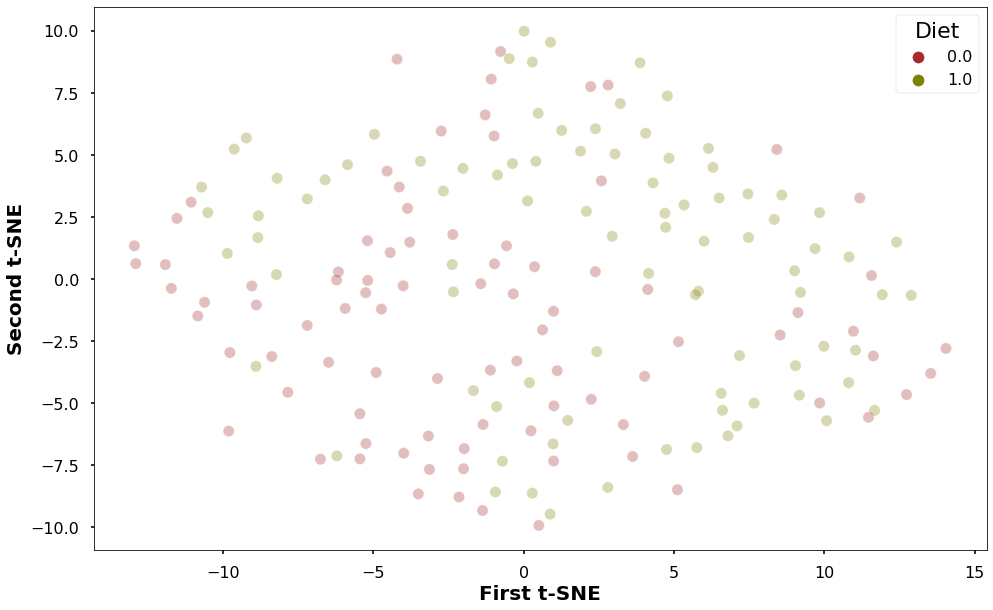

Logistic Regression: The best parameter combination is {'C': 100, 'class_weight': None, 'max_iter': 100, 'tol': 0.0001}
C-Support Vector Classification: The best parameter combination is {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
k-nearest Neighbours: The best parameter combination is {'metric': 'minkowski', 'n_neighbors': 10, 'weights': 'uniform'}
Random Forest: The best parameter combination is {'criterion': 'entropy', 'max_depth': 6, 'n_estimators': 100}
XGBoost: The best parameter combination is {'max_depth': 6, 'n_estimators': 200}


<Figure size 1296x1296 with 0 Axes>

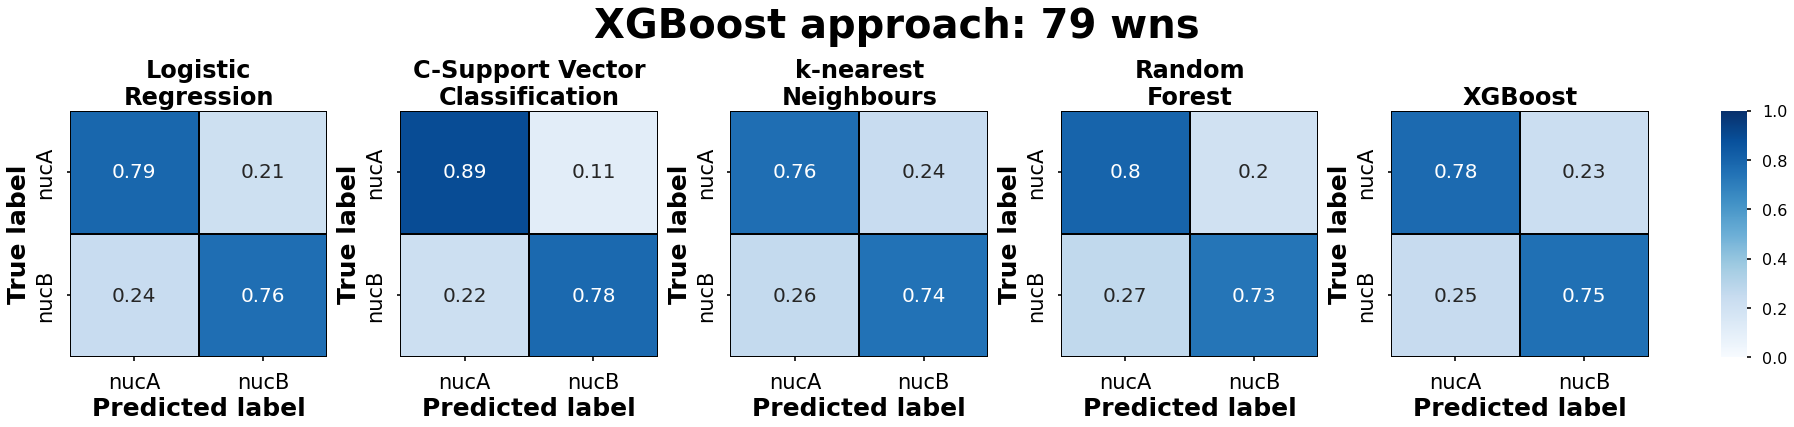

<Figure size 1296x1296 with 0 Axes>

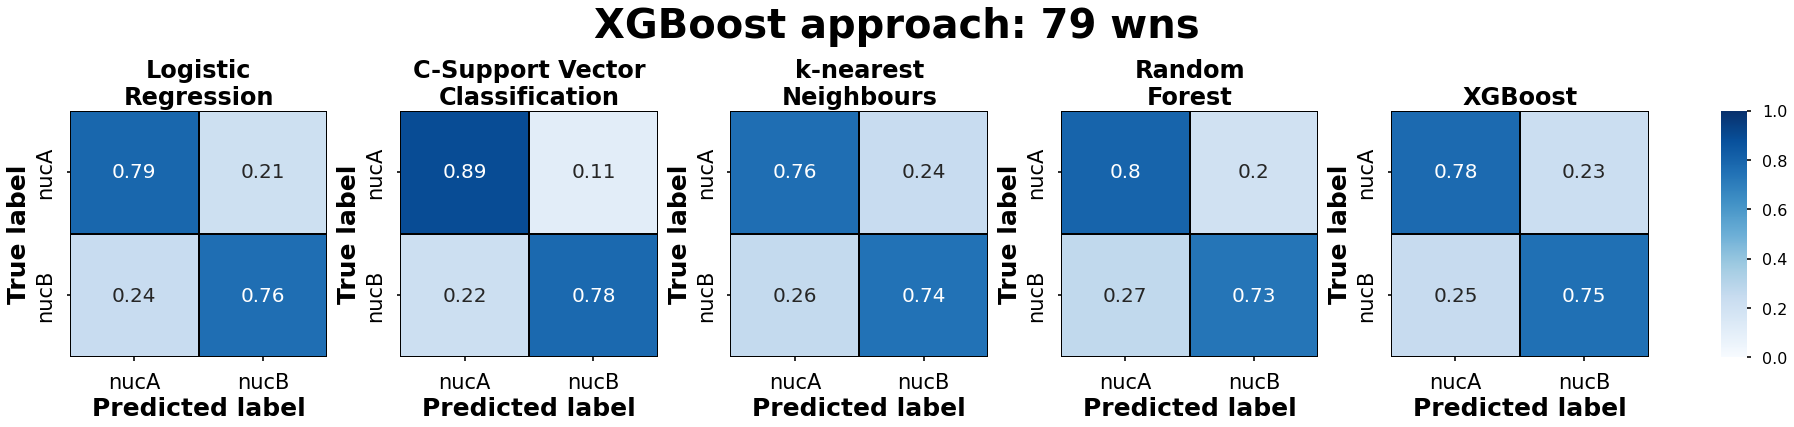

<Figure size 1296x1296 with 0 Axes>

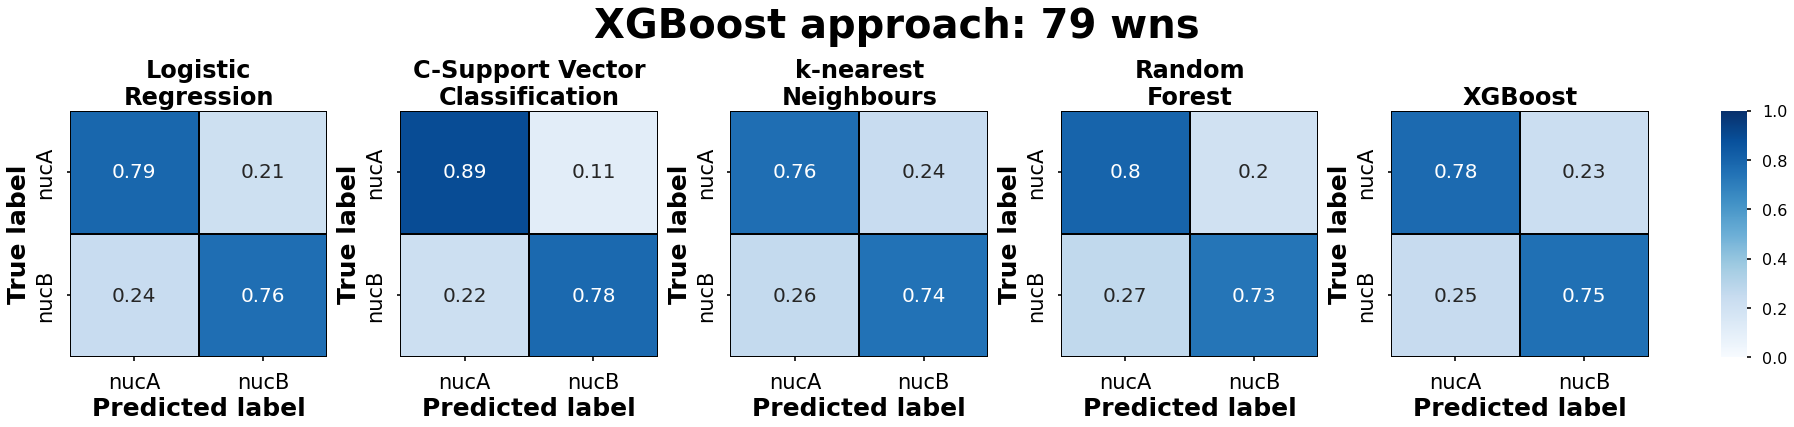

<Figure size 1296x1296 with 0 Axes>

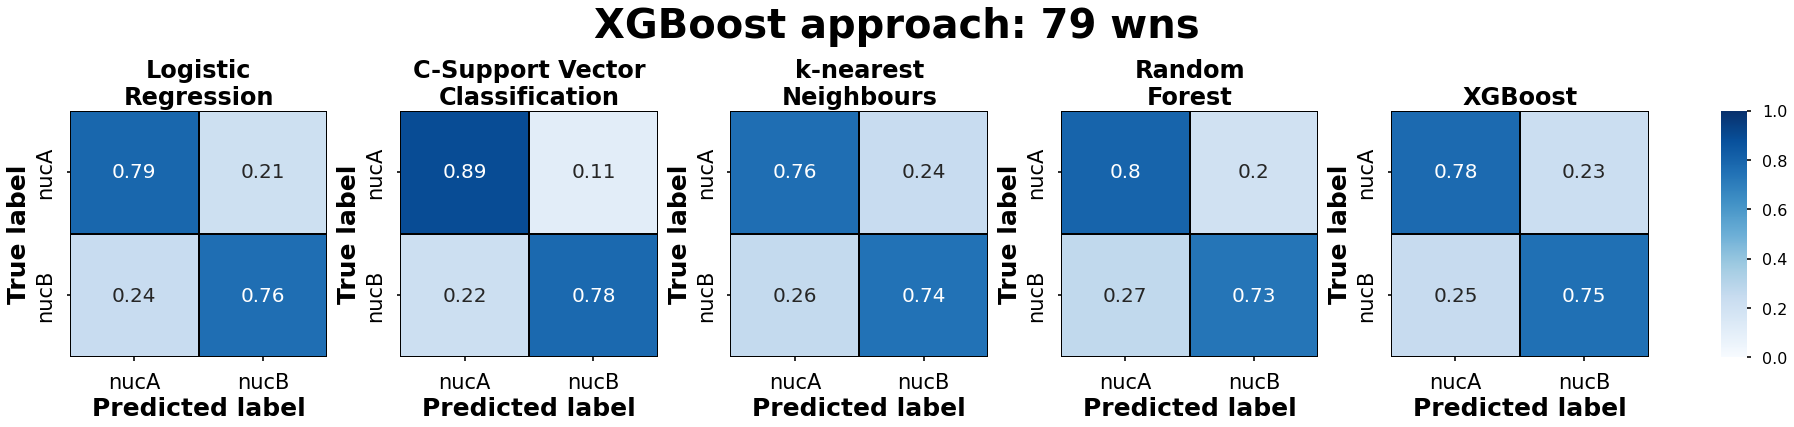

<Figure size 1296x1296 with 0 Axes>

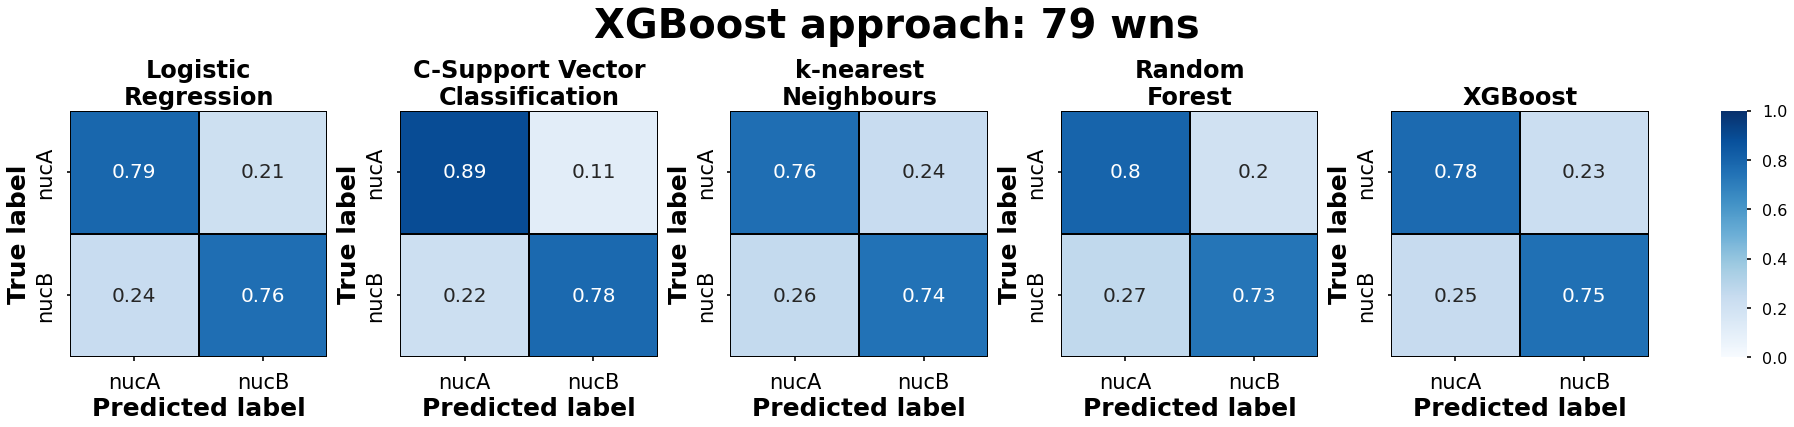

<Figure size 936x936 with 0 Axes>

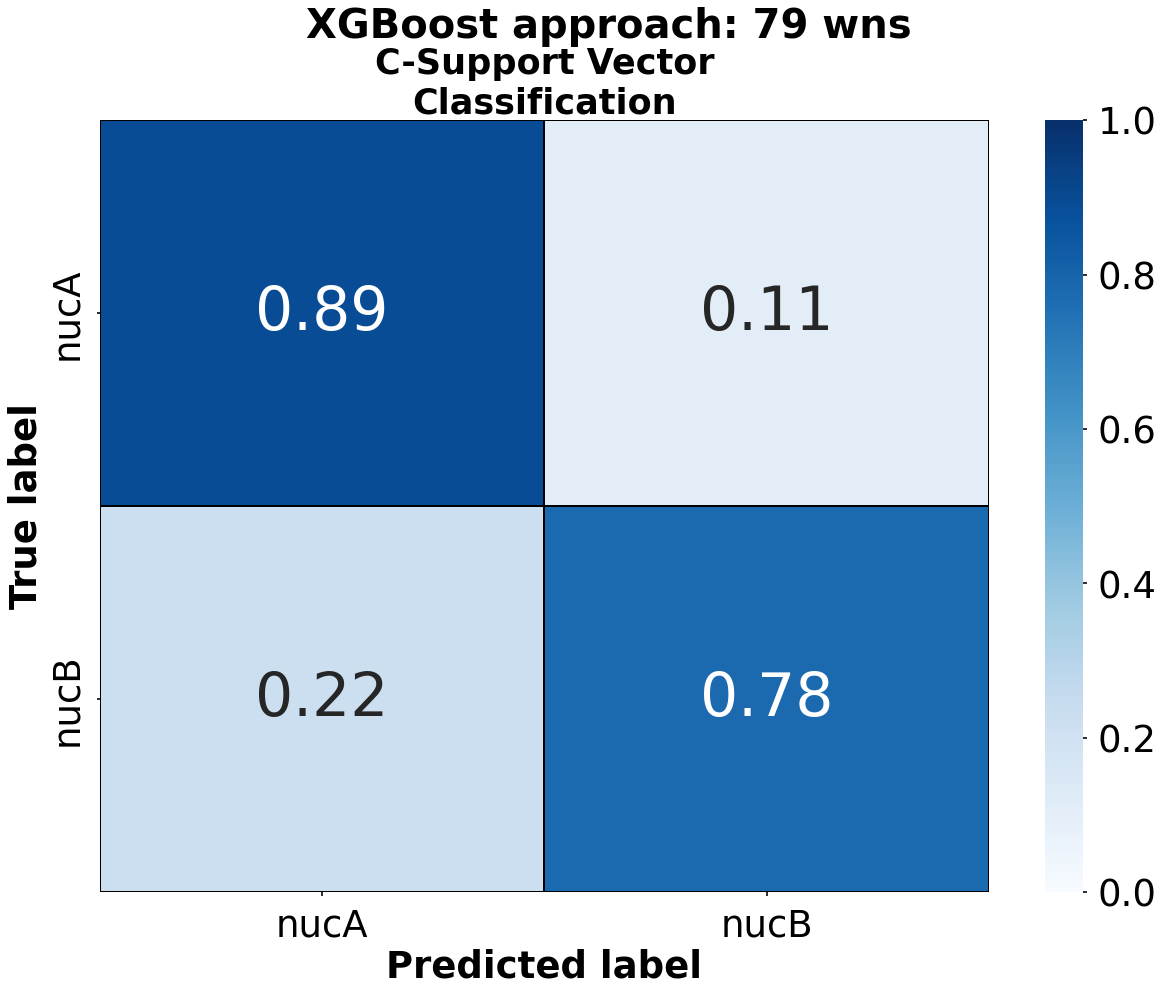

<Figure size 936x936 with 0 Axes>

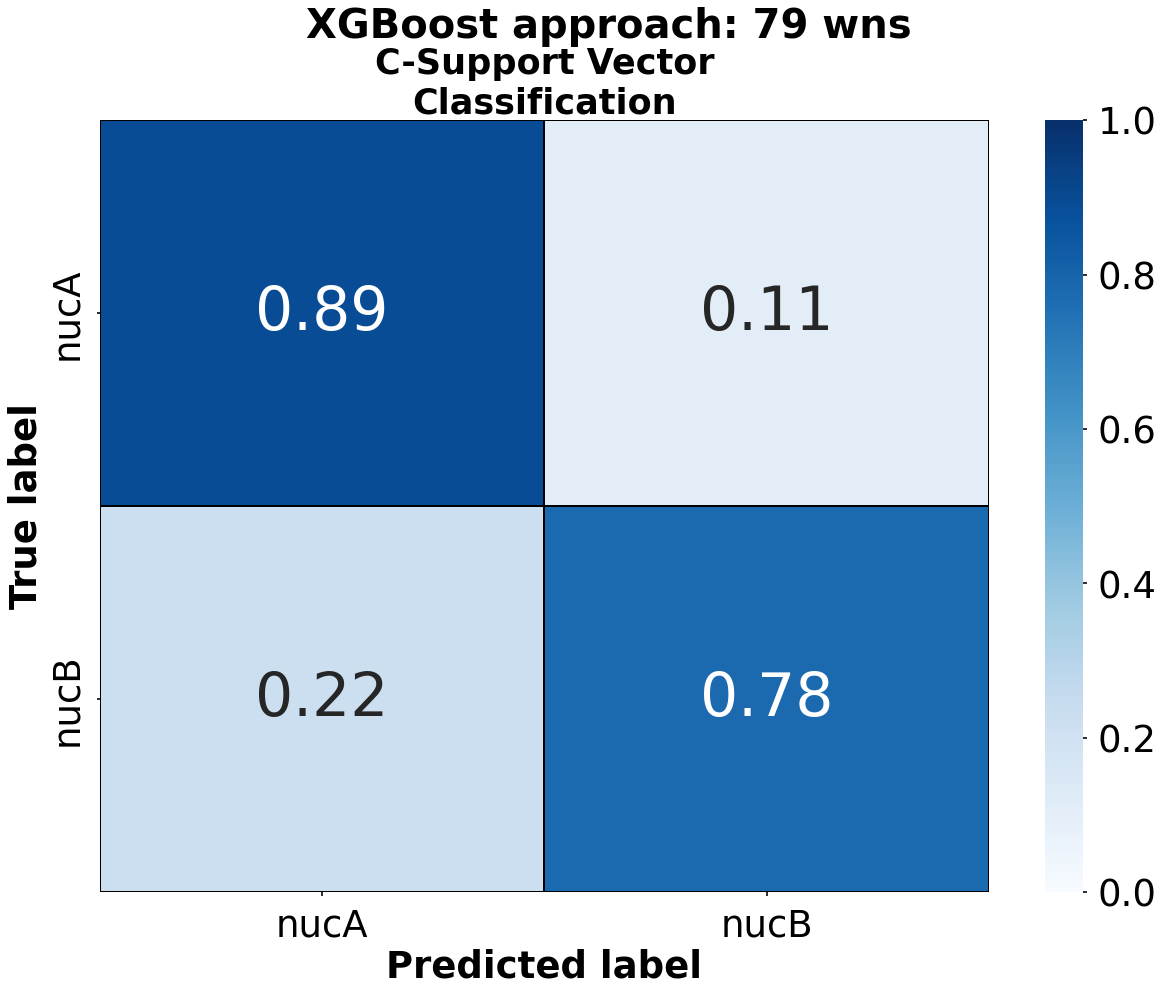

<Figure size 936x936 with 0 Axes>

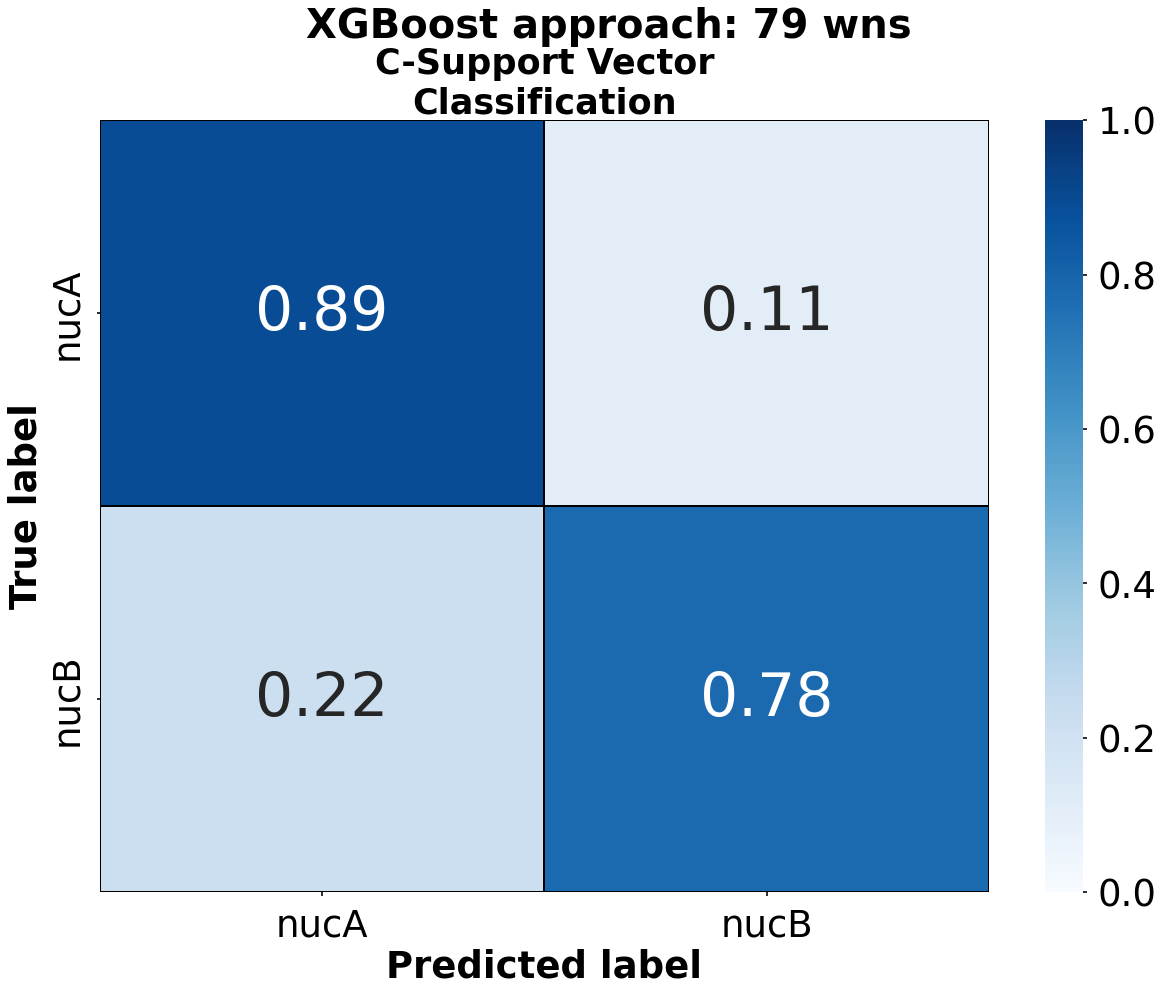

<Figure size 936x936 with 0 Axes>

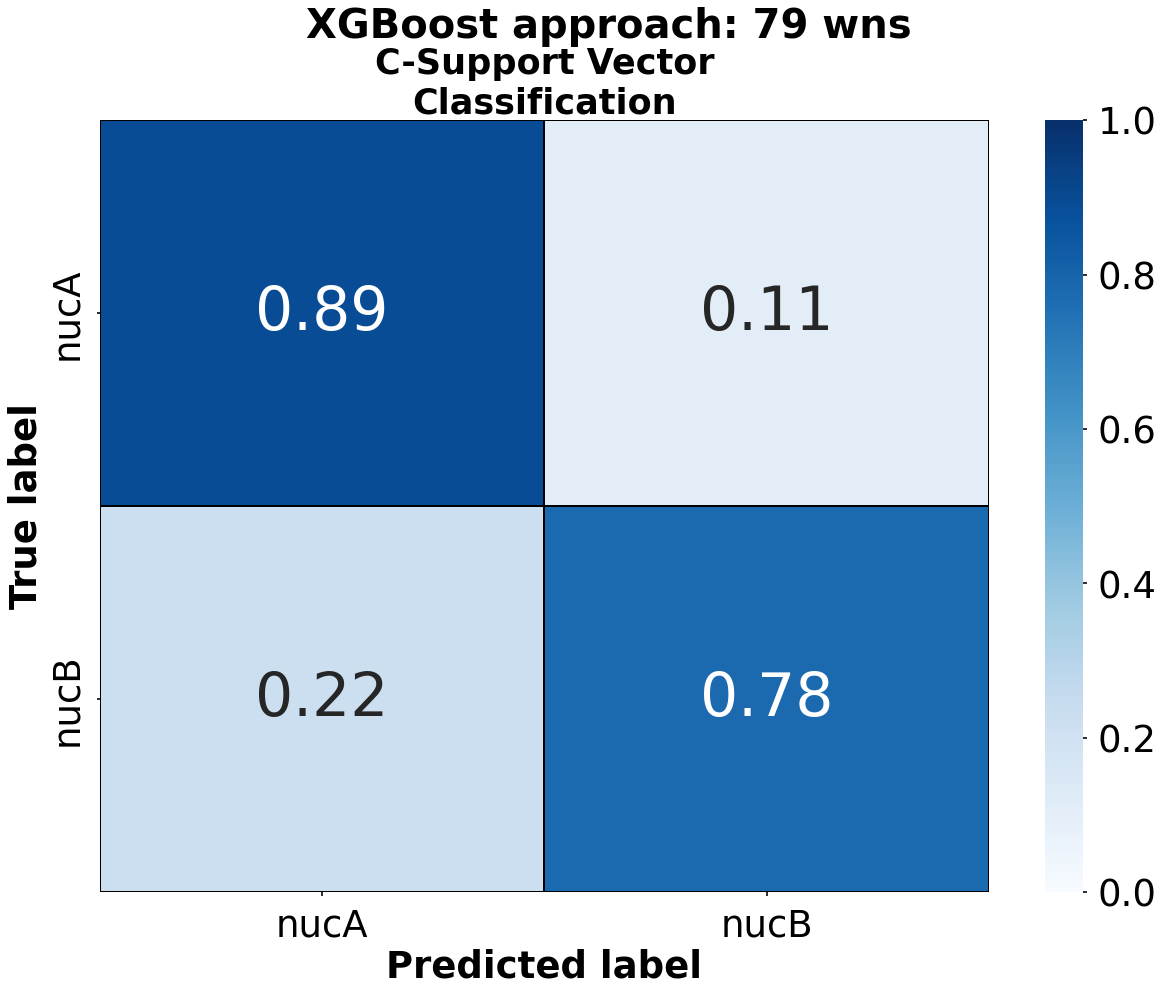

<Figure size 936x936 with 0 Axes>

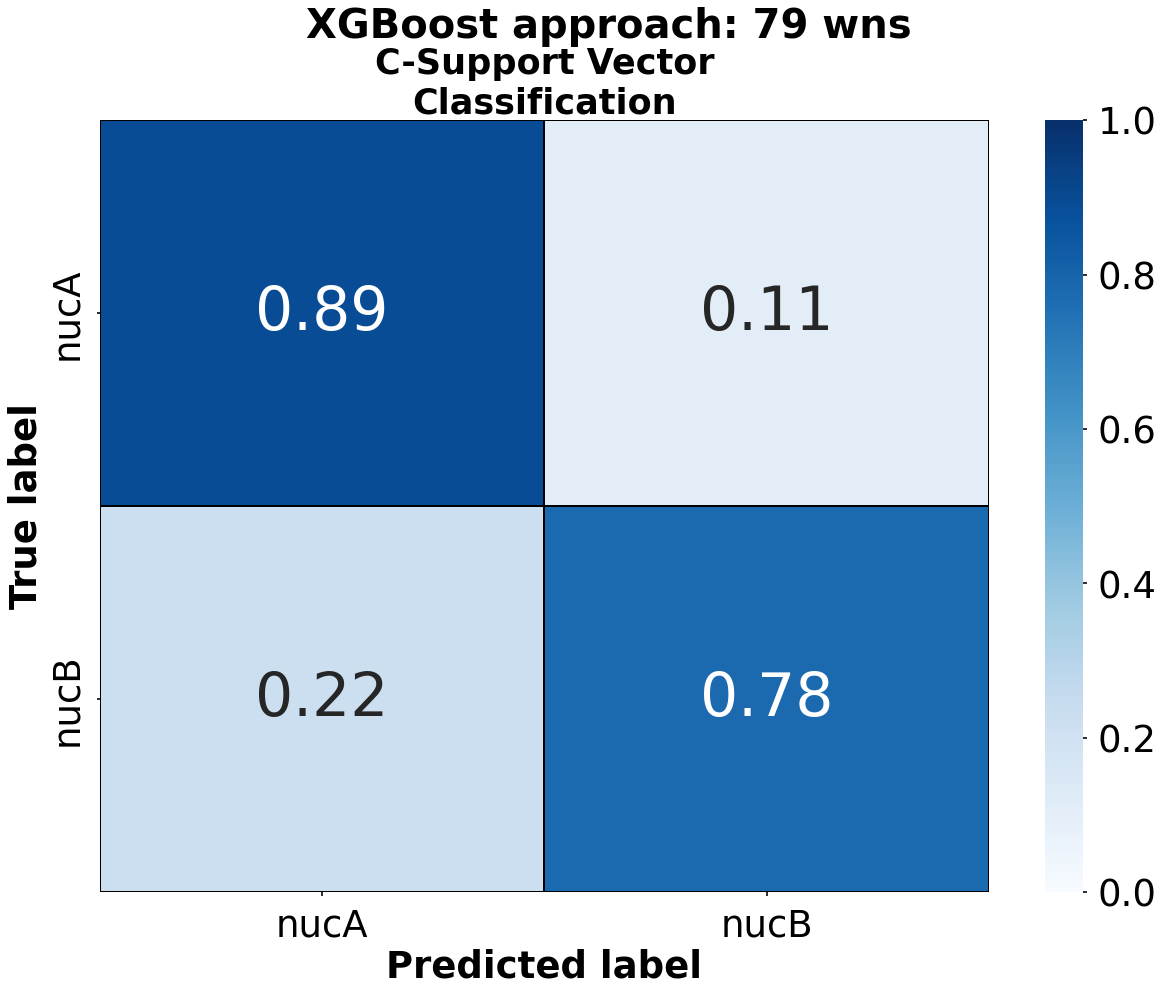

The Logistic Regression model had an accuracy of 77.50% ± 6.97%
[0.88888889 0.86111111 0.72222222 0.69444444 0.69444444 0.72222222
 0.86111111 0.88888889 0.72222222 0.72222222 0.91666667 0.75
 0.75       0.72222222 0.80555556 0.80555556 0.77777778 0.72222222
 0.72222222 0.75      ]
The C-Support Vector Classification model had an accuracy of 83.61% ± 5.89%
[0.86111111 0.86111111 0.77777778 0.77777778 0.75       0.80555556
 0.91666667 0.94444444 0.72222222 0.77777778 0.91666667 0.83333333
 0.83333333 0.80555556 0.88888889 0.88888889 0.86111111 0.86111111
 0.86111111 0.77777778]
The k-nearest Neighbours model had an accuracy of 75.28% ± 6.85%
[0.77777778 0.77777778 0.83333333 0.72222222 0.66666667 0.61111111
 0.86111111 0.77777778 0.66666667 0.69444444 0.88888889 0.75
 0.77777778 0.66666667 0.77777778 0.72222222 0.75       0.80555556
 0.80555556 0.72222222]
The Random Forest model had an accuracy of 77.36% ± 7.82%
[0.86111111 0.72222222 0.83333333 0.77777778 0.66666667 0.72222222
 0.9166

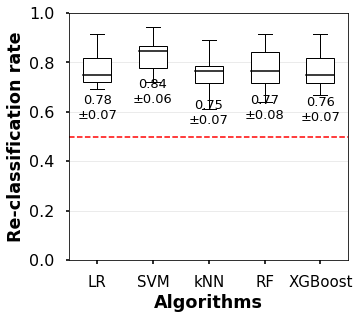

In [ ]:
MIRSPIPELINE (data=r"/Desktop/Diet1FTIR.dat",
       testdata_presence ="No",
       #if there is a test dataset put the file path. This only applies to the Sex and Geno datasets
       test_data=None, 
       
       # Select the name of the experiment
       experiment='Diet1', 

       #if experiment="Sex", and you want to create a dk category select 'Yes' otherwise None
       sex_dk=None,

       #If experiment is 'DGRP', select the list of sensitive or resistant flies identified from HRs in R
       ## if not 'DGRP', put None
       sensitives_file = None,
       resistants_file = None,
       
       ## if 'XGBoost', select the number of wns you want that are identified by XGBoost. e.g. 10, 25, 100 etc. If all, input "all"
       feature2='all', 
       tSNE_colours = {0.0: 'brown', 
                       1.0: 'olive'} ,     
       tSNE_order = [0.0, 1.0],
       
       plot_cols=['brown', 'olive'] , 
       labels=['nucA', 'nucB'], 
       styleofline='solid',
       
       # Select the folder where you want your results to be saved
       save_results_to= '/Desktop/results/' 
       )